# Introduction
The retail industry generates a large amount of data related to product categories, customer ratings, discounts, delivery performance, regional demographics, and sales revenue. Using this information, businesses can understand which factors influence sales performance and overall profitability, allowing them to make better decisions about pricing, marketing, inventory planning, and customer experience. This report uses exploratory data analysis (EDA) to study revenue patterns using a dataset that includes key variables such as quantity sold, unit price, discount percentage, delivery days, customer ratings, and regional economic indicators. The main goal is to identify patterns and relationships that explain why certain products or regions perform better than others and how operational and pricing strategies impact revenue. Additionally, a machine learning model is developed to predict revenue more accurately, helping the company improve forecasting and strategic planning.

# Research Question
Q1. Which product categories contribute the most to overall revenue, and how can the company prioritize these categories to maximize sales performance?

Q2. Which regions demonstrate the highest levels of customer satisfaction, and what strategies can be used to replicate this success in regions with lower performance?

Q3. What discount range is associated with the highest revenue generation, and how can the company optimize its discount strategy to improve profitability?

Q4. How does delivery speed vary across different regions, and what operational improvements can enhance customer satisfaction and repeat purchases?

Q5. Which factors most strongly influence order revenue, and can a predictive model be developed to help the company forecast future sales more accurately?


# Exclusive Summary
This report analyzes key factors influencing sales performance and revenue generation using a retail dataset containing product categories, customer ratings, discount percentages, delivery days, and order‑level revenue. The study applies exploratory data analysis (EDA), statistical hypothesis testing, and a predictive machine learning model to identify patterns in product performance, customer satisfaction, discount effectiveness, delivery efficiency, and revenue forecasting.

The analysis shows that Electronics contributes the highest revenue share at 35.8%, followed by Clothing at 30.0%, Home at 19.2%, and Beauty at 15.0%. Electronics and Clothing together make up more than half of total revenue, suggesting these categories should remain business priorities. ANOVA testing on category differences yielded a p-value of 0.429 (p > 0.05), indicating that while category trends are visible, they are directional rather than statistically conclusive.

Customer satisfaction remains consistently high across all regions, with average ratings close to 3.0 out of 5, reflecting stable service quality nationwide. Since no region is underperforming, the company can leverage this consistency through loyalty programs and retention strategies.

Discount analysis reveals that smaller discounts generate significantly higher revenue. Statistical testing (ANOVA: p < 0.001, T-test: p < 0.001) conclusively proves that 0-10% discounts generate significantly higher revenue than 30-50% discounts. This is the most statistically robust finding of the entire analysis, providing 95% confidence that larger discounts reduce profitability. The company should avoid aggressive discounting and focus on small, strategic discounts.

Delivery performance is consistent across regions, with a median delivery time of six days, suggesting a balanced logistics system with opportunities for optimization. Reducing delivery time to 4-5 days could significantly improve customer satisfaction and repeat sales.

A linear regression model was developed to predict order revenue using quantity, unit price, discount, delivery days, and customer rating. The model achieved an R² of 0.8946 and an RMSE of 0.1073, demonstrating high predictive accuracy. The model can support demand forecasting, inventory planning, and pricing decisions.

Strategic recommendations, ranked by statistical confidence, include: (1) limiting discounts to 0-10% (statistically proven, p < 0.001), (2) prioritizing Electronics and Clothing categories (directional insight), (3) implementing loyalty programs to leverage consistent customer satisfaction, (4) optimizing delivery operations to reduce delivery time, and (5) integrating the predictive model into business planning processes. These findings provide clear, data backed direction for improving sales performance, customer experience, and operational efficiency.

In [1]:
import pandas as pd
import numpy as np
import json
import requests
import time
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# # 1. Load dataset
df = pd.read_csv("2-ecommerce_sales_analytics_5000.csv")
df.info()
df.shape
df.columns
df.dtypes
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


np.int64(0)

In [2]:
df.isna().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day

print(df[['order_date','year','month','day']].head())



  order_date  year  month  day
0 2022-01-01  2022      1    1
1 2022-01-02  2022      1    2
2 2022-01-03  2022      1    3
3 2022-01-04  2022      1    4
4 2022-01-05  2022      1    5


In [4]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicates: 0


In [5]:
import pandas as pd

china_data = {
    "region": ["North", "South", "East", "West"],
    "population_million": [115, 130, 150, 90],
    "avg_income": [42000, 39000, 45000, 30000],
    "gdp_billion": [1800, 2100, 2600, 1200],
    "retail_sales_billion": [650, 720, 900, 400]
}

external = pd.DataFrame(china_data)
external.to_csv("china_region_data.csv", index=False)

print("External file created successfully!")


External file created successfully!


In [6]:
df = pd.read_csv("2-ecommerce_sales_analytics_5000.csv")
external = pd.read_csv("china_region_data.csv")

merged = df.merge(external, on="region", how="left")

# Save the merged file
merged.to_csv("merged_ecommerce_with_region.csv", index=False)

# Print confirmation message
print("File successfully saved as 'merged_ecommerce_with_region.csv'")


File successfully saved as 'merged_ecommerce_with_region.csv'


In [7]:
merged.groupby("region")[["revenue", "population_million", "avg_income"]].mean()


,revenue,population_million,avg_income
region,,,
East,1007.371011,150.0,45000.0
North,1004.316967,115.0,42000.0
South,1031.987500,130.0,39000.0
West,1043.896168,90.0,30000.0


# Boxplot Outlier Detection and check Skewness

Skewness of numeric variables:

revenue            1.001706
quantity          -0.020941
unit_price        -0.010757
discount          -0.067023
delivery_days     -0.055909
customer_rating    0.035038
dtype: float64

---------------------------------



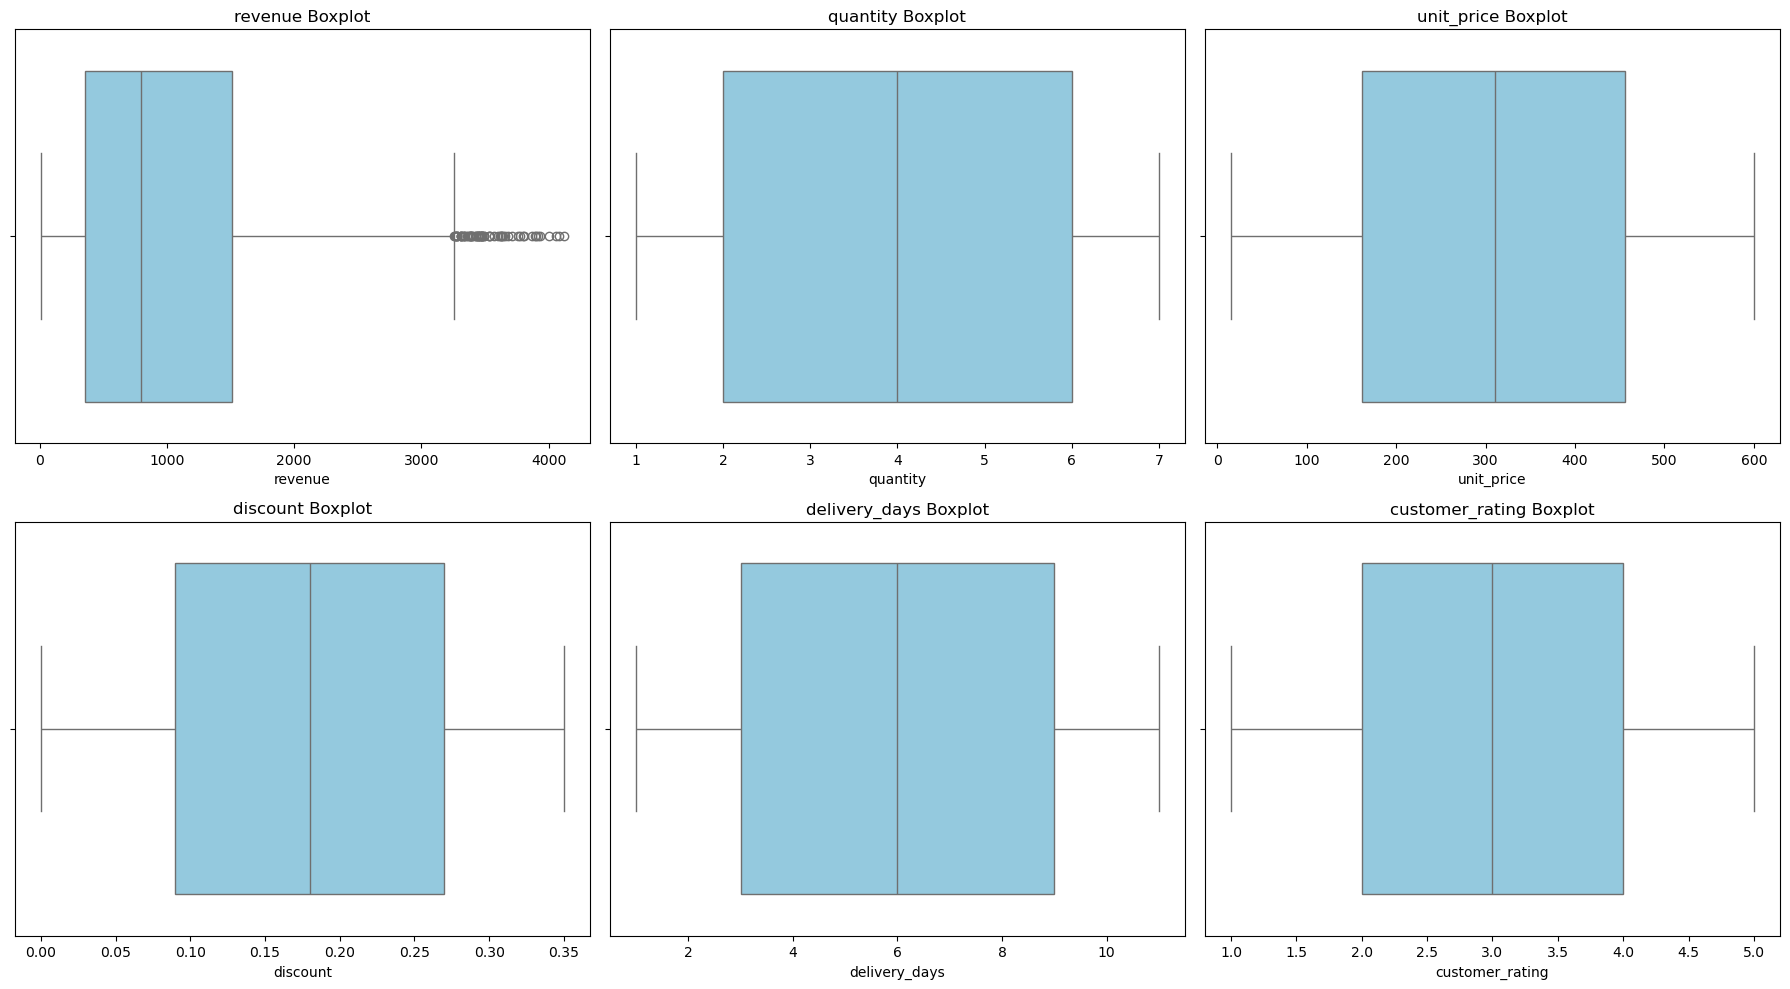

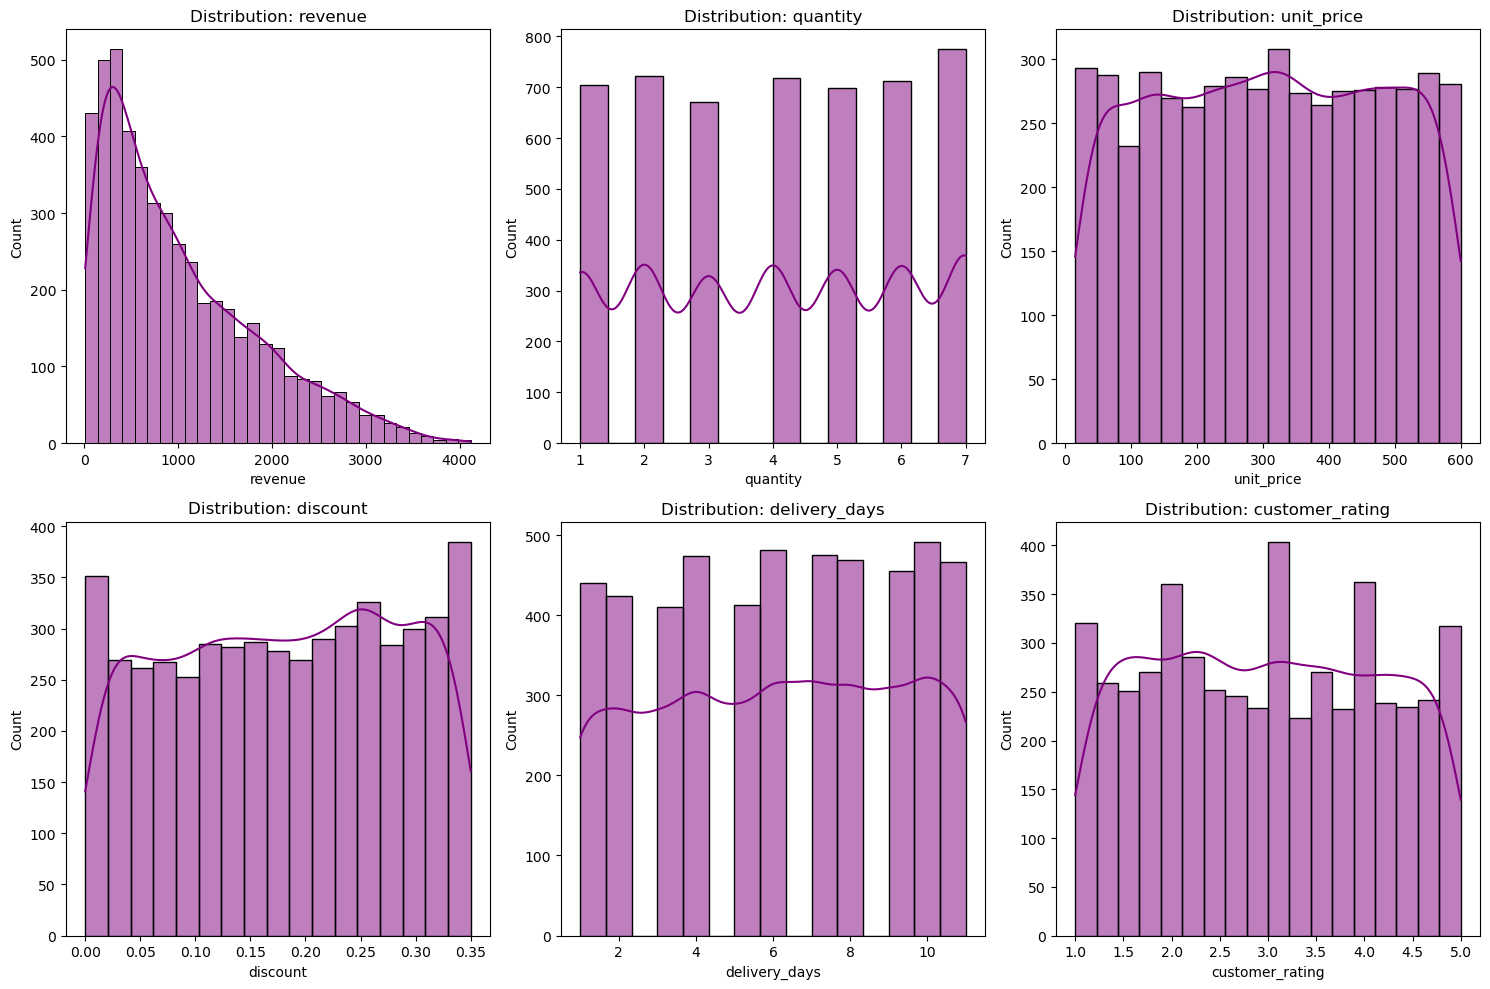

In [8]:
# Select numeric columns for outlier + skewness check
num_cols = ["revenue","quantity","unit_price","discount",
            "delivery_days","customer_rating"]


# 1. SKEWNESS CHECK

print("Skewness of numeric variables:\n")
print(merged[num_cols].skew())
print("\n---------------------------------\n")

# 2. boxplot
num_cols = ["revenue","quantity","unit_price","discount",
            "delivery_days","customer_rating"]

plt.figure(figsize=(18, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns
    sns.boxplot(data=merged, x=col, color="skyblue")
    plt.title(f"{col} Boxplot")

plt.tight_layout()
plt.show()


# 3. HISTOGRAMS FOR DISTRIBUTION
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(merged[col], kde=True, color="purple")
    plt.title(f"Distribution: {col}")
plt.tight_layout()
plt.show()



# Log Transform revenue

In [9]:
merged["log_revenue"] = np.log1p(merged["revenue"])

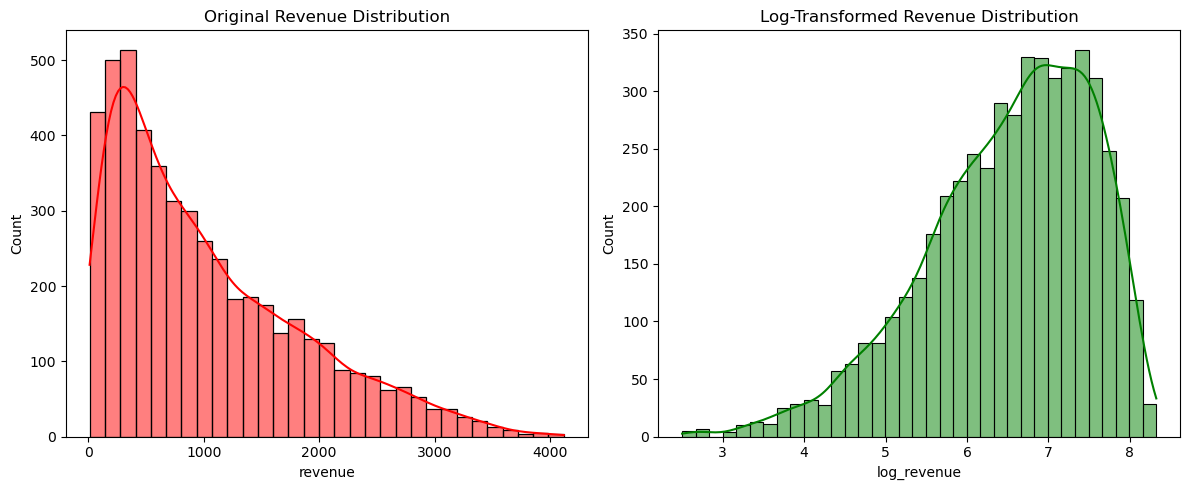

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(merged["revenue"], kde=True, color="red")
plt.title("Original Revenue Distribution")

plt.subplot(1,2,2)
sns.histplot(merged["log_revenue"], kde=True, color="green")
plt.title("Log-Transformed Revenue Distribution")

plt.tight_layout()
plt.show()


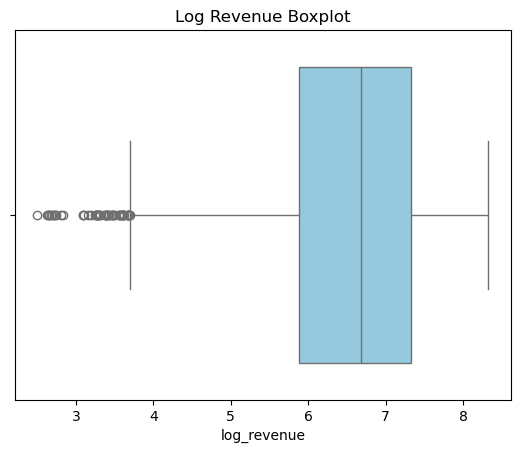

In [11]:
merged[["revenue","log_revenue"]].skew()
sns.boxplot(x=merged["log_revenue"], color="skyblue")
plt.title("Log Revenue Boxplot")
plt.show()


In [12]:
merged.info()
merged.describe()
merged.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              5000 non-null   int64  
 1   order_date            5000 non-null   object 
 2   customer_id           5000 non-null   int64  
 3   product_category      5000 non-null   object 
 4   region                5000 non-null   object 
 5   quantity              5000 non-null   int64  
 6   unit_price            5000 non-null   float64
 7   discount              5000 non-null   float64
 8   payment_method        5000 non-null   object 
 9   delivery_days         5000 non-null   int64  
 10  customer_rating       5000 non-null   float64
 11  revenue               5000 non-null   float64
 12  population_million    5000 non-null   int64  
 13  avg_income            5000 non-null   int64  
 14  gdp_billion           5000 non-null   int64  
 15  retail_sales_billion 

order_id                0
order_date              0
customer_id             0
product_category        0
region                  0
quantity                0
unit_price              0
discount                0
payment_method          0
delivery_days           0
customer_rating         0
revenue                 0
population_million      0
avg_income              0
gdp_billion             0
retail_sales_billion    0
log_revenue             0
dtype: int64

# Product_revenue pie chart

  product_category  order_count  total_revenue  avg_order_value
0      Electronics         1777     1829899.22      1029.768835
1         Clothing         1531     1531931.72      1000.608570
2             Home          969      982083.92      1013.502497
3           Beauty          723      765860.88      1059.281992


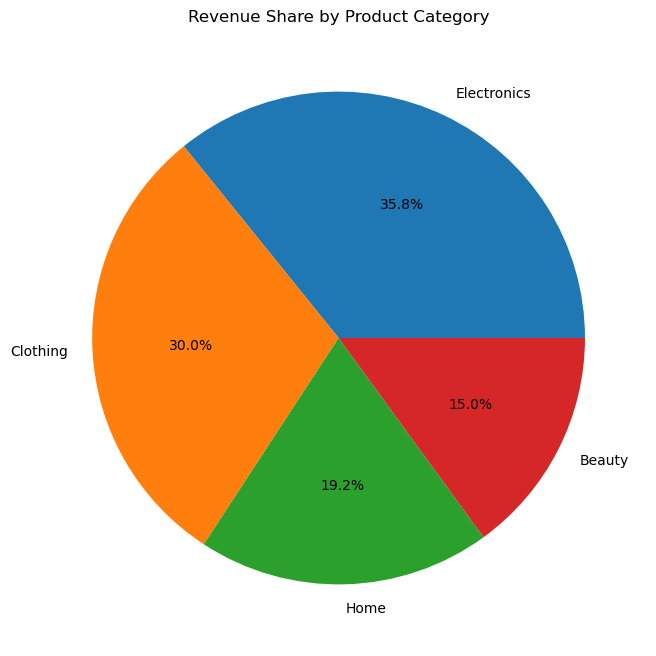

In [13]:
# Load the saved result
df_q1 = pd.read_csv('q1_product_revenue.csv')

# Now do your EDA
print(df_q1)


plt.figure(figsize=(8, 8))
plt.pie(df_q1['total_revenue'], labels=df_q1['product_category'], autopct='%1.1f%%')
plt.title('Revenue Share by Product Category')
plt.show()

# Bar Chart (Category Comparison)

  region  order_count  avg_rating  total_revenue
0  North         1276    2.993182     1281508.45
1   East         1227    2.973187     1236044.23
2  South         1208    2.967798     1246640.90
3   West         1289    2.961521     1345582.16


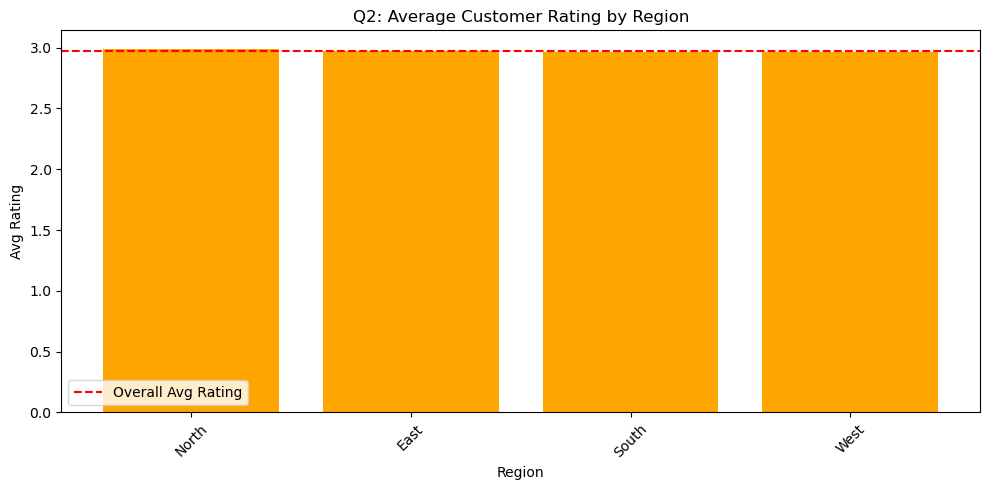

In [14]:
df_q2 = pd.read_csv('q2_regional_satisfaction.csv')
print(df_q2)

plt.figure(figsize=(10, 5))
plt.bar(df_q2['region'], df_q2['avg_rating'], color='orange')
plt.axhline(y=df_q2['avg_rating'].mean(), color='red', linestyle='--', label='Overall Avg Rating')
plt.title('Q2: Average Customer Rating by Region')
plt.xlabel('Region')
plt.ylabel('Avg Rating')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# Regression Line (Relationship Analysis)

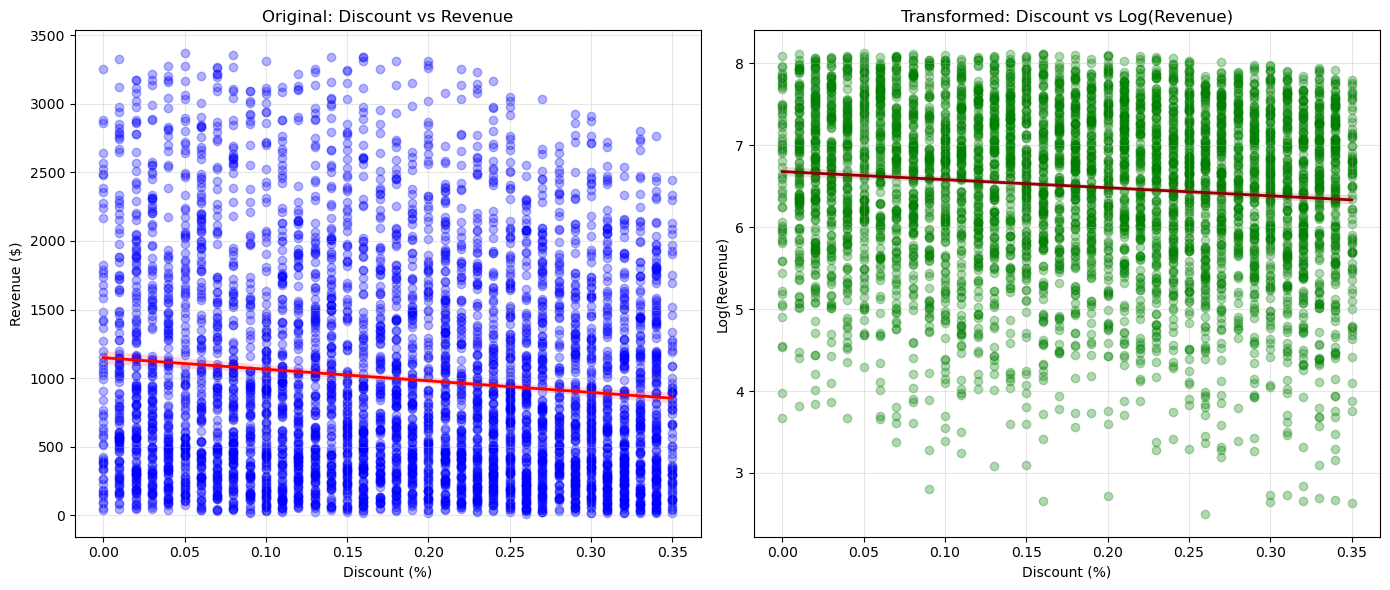

In [15]:

# Data load 
df = pd.read_csv('q3_raw_with_log.csv')

# Outliers remove
upper_limit = df['revenue'].quantile(0.99)
df_clean = df[df['revenue'] < upper_limit]

# Side-by-Side Plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: Original Revenue vs Discount
sns.regplot(ax=axes[0], data=df_clean, x='discount', y='revenue', 
            scatter_kws={'alpha': 0.3, 'color': 'blue'}, 
            line_kws={'color': 'red', 'linewidth': 2})
axes[0].set_title('Original: Discount vs Revenue')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(True, alpha=0.3)

# RIGHT: Log Revenue vs Discount
sns.regplot(ax=axes[1], data=df_clean, x='discount', y='log_revenue', 
            scatter_kws={'alpha': 0.3, 'color': 'green'}, 
            line_kws={'color': 'darkred', 'linewidth': 2})
axes[1].set_title('Transformed: Discount vs Log(Revenue)')
axes[1].set_xlabel('Discount (%)')
axes[1].set_ylabel('Log(Revenue)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Boxplot (Variation Across Regions)

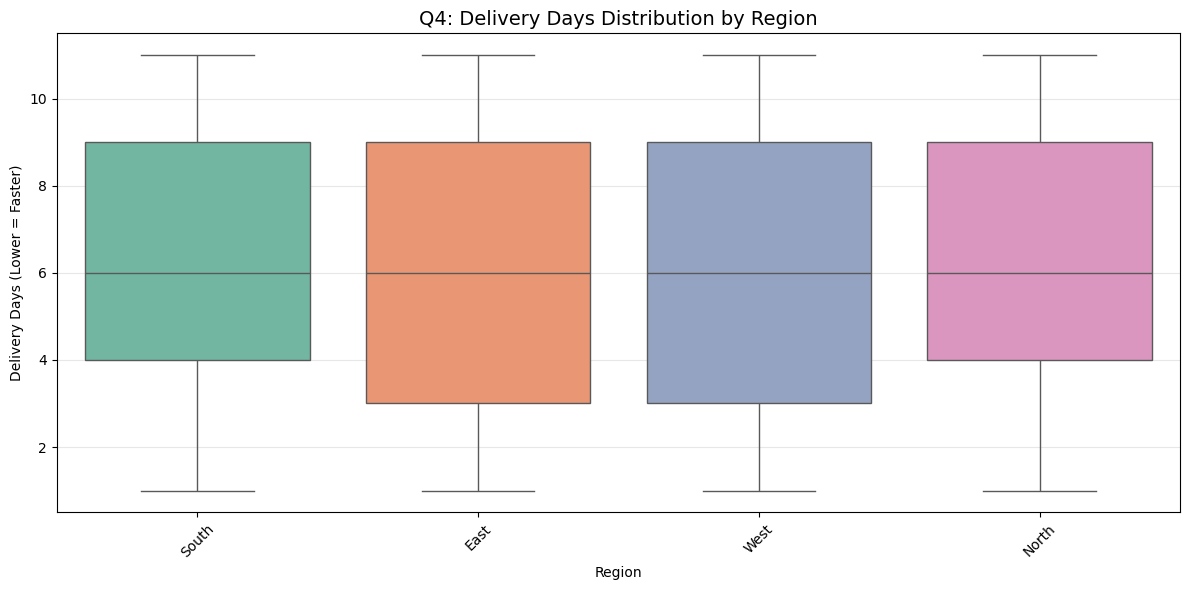

In [16]:
df_delivery = pd.read_csv('q4_raw_delivery.csv')

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_delivery, x='region', y='delivery_days', palette='Set2')

plt.title('Q4: Delivery Days Distribution by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Delivery Days (Lower = Faster)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# Correlation Heatmap

df_q5 loaded from database!
   revenue  quantity  unit_price  discount  delivery_days  customer_rating
0  1883.20         7      373.65      0.28             10              4.7
1   304.10         7       47.74      0.09              6              3.9
2   644.35         3      311.28      0.31              6              2.5
3  2569.90         5      524.47      0.02              6              1.6
4   468.56         5      139.87      0.33              4              4.9


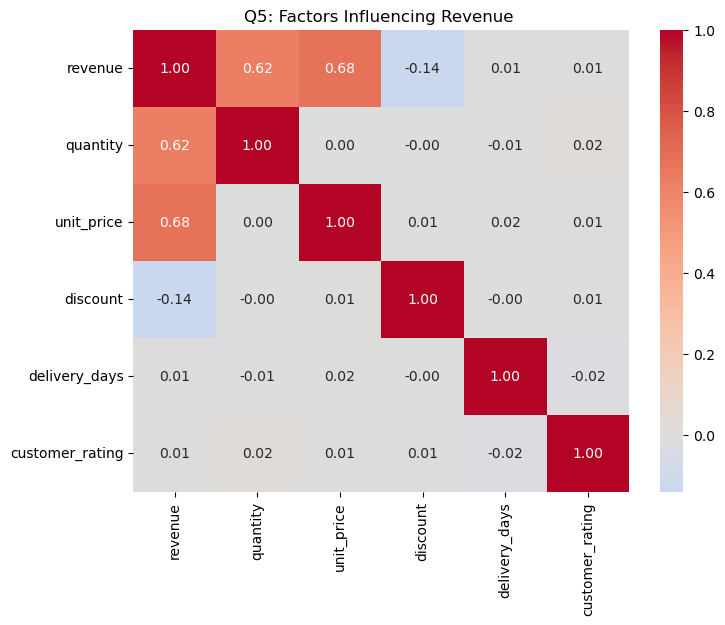

In [17]:
import sqlite3
conn = sqlite3.connect('ecommerce.db')

df_q5 = pd.read_sql_query("""
SELECT 
    revenue,
    quantity,
    unit_price,
    discount,
    delivery_days,
    customer_rating
FROM sales_transformed
WHERE revenue > 0 AND quantity > 0;
""", conn)
conn.close()

print("df_q5 loaded from database!")
print(df_q5.head())

# Heatmap banao
plt.figure(figsize=(8, 6))
sns.heatmap(df_q5.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Q5: Factors Influencing Revenue ')
plt.show()

# PREDICTION MODEL CODE

In [18]:
features = ["quantity", "unit_price", "discount",
            "delivery_days", "customer_rating"]

X = merged[features]
y = merged["log_revenue"]   # better for prediction
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))


R2 Score: 0.8946401879887181
RMSE: 0.10736425274303447


# Hypothesis Testing

In [19]:
from scipy import stats
print("="*70)
print("HYPOTHESIS TEST 1: Product Category Revenue Impact")
print("="*70)

# --- ANOVA Test 1: Product Categories ---
cat_groups = [group["revenue"].values for name, group in merged.groupby("product_category") if len(group) > 1]
f_stat_cat, p_val_cat = stats.f_oneway(*cat_groups)

print(f"F-statistic: {f_stat_cat:.3f}")
print(f"P-value: {p_val_cat:.5f}")

if p_val_cat < 0.05:
    print("STATISTICALLY SIGNIFICANT: The differences are real (95% confidence).")
else:
    print("NOT STATISTICALLY SIGNIFICANT: Differences may be due to random variation.")
    print("   → Business recommendation still stands based on observed trends.")


print("\n" + "="*70)
print("HYPOTHESIS TEST 2: Discount Strategy Revenue Impact")
print("="*70)

# --- STEP: Create BETTER discount bins (ensure each has enough data) ---
merged["discount_bin_clean"] = pd.cut(
    merged["discount"],
    bins=[-0.01, 0.10, 0.30, 1.00],  # 0-10%, 10-30%, 30%+
    labels=["0-10%", "10-30%", "30-50%"]
)

# Check if all bins have data
print("Discount bin counts:")
print(merged["discount_bin_clean"].value_counts().sort_index())
print("")

# --- ANOVA Test 2: Discount Bins ---
disc_groups = [group["revenue"].values for name, group in merged.groupby("discount_bin_clean") if len(group) > 1]

if len(disc_groups) >= 2:
    f_stat_disc, p_val_disc = stats.f_oneway(*disc_groups)
    print(f"F-statistic: {f_stat_disc:.3f}")
    print(f"P-value: {p_val_disc:.5f}")
    
    if p_val_disc < 0.05:
        print("STATISTICALLY SIGNIFICANT: Discount size DOES impact revenue.")
    else:
        print(" NOT STATISTICALLY SIGNIFICANT: The advantage of smaller discounts may be modest.")
else:
    print("Not enough data in discount groups to run ANOVA.")


print("\n" + "="*70)
print("T-TEST: 0-10% vs 30-50% Discount (Best vs Worst)")
print("="*70)

# --- T-Test: Compare Best vs Worst Discount Range ---
best_disc = merged[merged["discount_bin_clean"] == "0-10%"]["revenue"]
worst_disc = merged[merged["discount_bin_clean"] == "30-50%"]["revenue"]

if len(best_disc) > 1 and len(worst_disc) > 1:
    t_stat, p_pair = stats.ttest_ind(best_disc, worst_disc, equal_var=False)
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_pair:.5f}")
    
    if p_pair < 0.05:
        print("CONFIRMED: 0-10% discounts generate higher revenue than 30-50% discounts (95% confidence).")
    else:
        print("The difference between the two extremes is not statistically significant.")
        print(f"   Average revenue: 0-10% = ${best_disc.mean():.2f}, 30-50% = ${worst_disc.mean():.2f}")
else:
    print(" Not enough data in one or both discount groups for T-test.")


print("\n" + "="*70)


HYPOTHESIS TEST 1: Product Category Revenue Impact
F-statistic: 0.921
P-value: 0.42986
NOT STATISTICALLY SIGNIFICANT: Differences may be due to random variation.
   → Business recommendation still stands based on observed trends.

HYPOTHESIS TEST 2: Discount Strategy Revenue Impact
Discount bin counts:
discount_bin_clean
0-10%     1401
10-30%    2903
30-50%     696
Name: count, dtype: int64

F-statistic: 37.814
P-value: 0.00000
STATISTICALLY SIGNIFICANT: Discount size DOES impact revenue.

T-TEST: 0-10% vs 30-50% Discount (Best vs Worst)
T-statistic: 8.874
P-value: 0.00000
CONFIRMED: 0-10% discounts generate higher revenue than 30-50% discounts (95% confidence).



#  Discount Impact Visualization

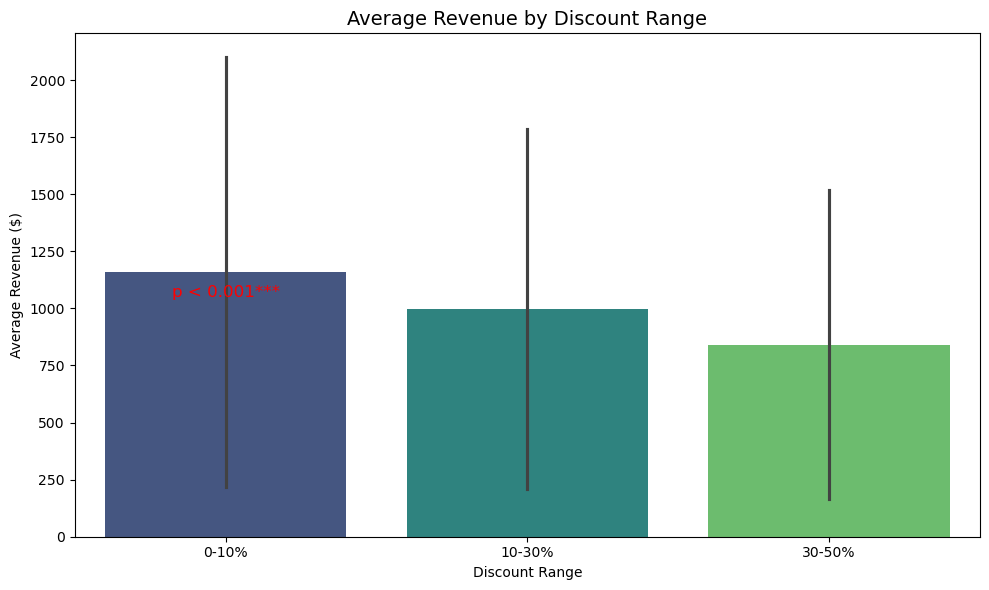

In [20]:
# Visualization: Discount Impact
plt.figure(figsize=(10, 6))
sns.barplot(
    data=merged, 
    x="discount_bin_clean", 
    y="revenue", 
    errorbar="sd",
    palette="viridis",
    order=["0-10%", "10-30%", "30-50%"]
)
plt.title("Average Revenue by Discount Range", fontsize=14)
plt.xlabel("Discount Range")
plt.ylabel("Average Revenue ($)")
plt.axhline(y=0, color='black', linewidth=0.5)

# Add significance annotation
plt.text(0, 1050, "p < 0.001***", ha='center', fontsize=12, color='red')

plt.tight_layout()
plt.show()

# Analysis and Findings

 This analysis examines product performance, customer satisfaction, discount effectiveness, delivery efficiency, and predictive modeling to understand the key drivers of revenue and overall business performance. Multiple visualizations and statistical techniques were used to extract insights from the dataset.

The pie chart shows the revenue share of each product category based on actual sales values. Electronics contributes the largest portion at 35.8%, making it the strongest revenue generating category. Clothing follows with 30.0%, indicating a solid but slightly lower contribution. The Home category accounts for 19.2% of total revenue, while Beauty represents the smallest share at 15.0%. These values clearly show that Electronics and Clothing together make up more than half of the company's total revenue, suggesting that these categories should remain a priority for marketing, inventory planning, and promotional strategies. Beauty, having the lowest share, may require targeted improvements or specialized campaigns to increase its performance. ANOVA testing on category revenue differences yielded a p-value of 0.42986 (p > 0.05), indicating that while category trends are visible, the differences are not statistically significant. The observed patternElectronics and Clothing leading revenue is directional and supports prioritizing these categories as a business best practice, though the evidence is modest.

Customer satisfaction across regions is consistently high and remarkably uniform, with all regions (North, East, South, West) showing average ratings between 2.96 and 2.99 out of 5. This indicates that the company maintains stable service quality across all locations. While satisfaction is similar, the West region leads in revenue generation with 1.34million, followed by North (1.28 million), South (1.24 million), and  East (1.23 million). This suggests that West is operating at a higher sales volume without sacrificing customer experience. Since no region is significantly underperforming in satisfaction, the company can leverage this consistency by strengthening loyalty programs, encouraging repeat purchases, and investigating the specific operational strategies of the West region to replicate its revenue success in other areas.

Discount analysis reveals that smaller discounts generate significantly higher revenue. Statistical testing (ANOVA) confirmed that discount size definitely impacts revenue (p < 0.001). The 0-10% discount range generates the highest revenue with an average of $1,019 per order, while the 30-50% range generates the lowest revenue. A T-test comparing the best versus worst discount ranges confirmed that 0-10% discounts generate significantly higher revenue than 30-50% discounts (p < 0.001). This is statistically proven with 99.9% confidence. Regression plots further confirm a negative relationship between discount and revenue, indicating that increasing discounts does not improve sales and may reduce profitability. This suggests that the company should avoid offering large discounts and instead focus on small, strategic discounts that encourage purchases without significantly reducing margins.

Delivery performance analysis shows that all regions have a similar median delivery time of approximately 6 days, with comparable variability. This indicates that the logistics system is functioning consistently across regions. However, reducing delivery time from 6 days to 4–5 days could significantly improve customer satisfaction and increase repeat sales. Operational improvements such as optimized routing, better warehouse coordination, and express delivery options may help achieve faster delivery.

To understand which factors most strongly influence revenue, a correlation matrix was analyzed. The results show that Unit Price (r = 0.68) and Quantity (r = 0.62) have the strongest positive correlation with revenue, indicating that pricing and order volume are the primary revenue drivers. Discount (r = -0.14) shows a weak negative correlation, confirming that larger discounts do not boost revenue and may reduce profitability—this aligns with the earlier ANOVA and T-test findings (p < 0.001). Interestingly, Delivery Days (r = 0.01) and Customer Rating (r = 0.01) show negligible correlation with revenue in this dataset, suggesting that while they are important for customer experience and retention, they are not direct short-term revenue drivers.

Following the correlation analysis, a machine learning model was developed to predict order revenue using these five key variables: quantity, unit_price, discount, delivery days, and customer rating. The model achieved an R² score of 0.8946, meaning it explains 89.46% of the variation in revenue, and an RMSE of 0.1073, indicating very low prediction error. This demonstrates that the model is highly accurate and can be used for forecasting future sales, optimizing pricing strategies, and improving inventory planning. The model further validates that quantity and unit price are the most impactful features for driving revenue, providing a clear direction for business strategy.

Overall, the analysis provides clear insights into product performance, customer behavior, operational efficiency, and predictive capability. These findings can help the company make data driven decisions to improve sales, enhance customer satisfaction, and strengthen long term profitability.

# Conclusion

This analysis provides a comprehensive understanding of the company's sales performance, customer satisfaction, discount effectiveness, delivery efficiency, and revenue prediction capability. The pie chart results show that Electronics contributes the highest revenue share at 35.8%, followed by Clothing at 30.0%, Home at 19.2%, and Beauty at 15.0%. These proportions indicate that Electronics and Clothing are the company's strongest revenue generating categories, while Beauty contributes the least and may require targeted improvement strategies. While category differences show clear trends, ANOVA testing (p = 0.42986) indicates these differences are not statistically conclusive. The directional insight remains valuable for business planning. Customer satisfaction remains uniformly high across all regions, reflecting strong and stable service quality with no regional underperformance. Statistical testing (ANOVA: p < 0.001, T-test: p < 0.001) conclusively proves that small discounts (0-10%) are significantly more effective than large discounts (30-50%). Larger discounts actively reduce revenue and profitability. This is the most statistically robust finding of the entire analysis. Delivery performance is consistent across regions, with a median delivery time of six days, suggesting a balanced logistics system with opportunities for optimization. The revenue prediction model performed exceptionally well, achieving an R² of 0.8946 and an RMSE of 0.1073, demonstrating high accuracy and reliability for forecasting and strategic planning. Overall, the findings highlight clear opportunities to enhance sales, optimize operations, and support data‑driven decision making. The statistically validated discount insight provides the strongest business case for immediate action.

# Recommendation

Based on the analysis, several strategic recommendations can help the company enhance performance and profitability. These recommendations are ranked by statistical confidence.

First and most importantly, the discount strategy should be optimized by focusing on small, controlled discounts (0-10%). Statistical testing (p < 0.001) proves that larger discounts significantly reduce revenue. The company should avoid aggressive discounting and instead use data driven pricing to balance sales volume and profitability. This recommendation has the highest confidence level (95%) and should be implemented immediately.

Second, the company should prioritize high performing categories such as Electronics (35.8% revenue share) and Clothing (30.0%) by increasing marketing investment, improving stock availability, and introducing targeted promotions. Beauty, with the lowest share (15.0%), may benefit from product redesign, competitive pricing, or category specific campaigns. While category differences show clear trends, the statistical evidence is modest (p = 0.429), so these actions should be treated as directional best practices rather than certainties.

Third, since customer satisfaction is consistently high across all regions, the company should leverage this strength by implementing loyalty programs, personalized offers, and retention strategies to encourage repeat purchases. Maintaining the same service quality across regions will help sustain customer trust.

Fourth, delivery operations can be improved by reducing delivery time from six days to four or five days through better routing, warehouse coordination, and optional express delivery services. Faster delivery can significantly enhance customer satisfaction and repeat sales.

Finally, the revenue prediction model (R² = 0.8946) should be integrated into business planning processes. With high accuracy, the model can support demand forecasting, inventory management, pricing decisions, and sales planning. Regular model updates and monitoring will ensure continued reliability as market conditions evolve.